# Detection gallery: predictions vs. ground truth

Qualitative look at the selected detector (YOLO11n, `e1_baseline`) on the test session (E). Each panel pair shows
the auto-generated ground truth (left) and the predictions with confidence ≥ 0.25 (right). Images are session z maps
of the mean power of 5 trials (`RdBu_r`, z −4…+4; blue = power decrease/ERD, red = increase/ERS); panels from top
to bottom are C5, C3, Cz, C4, C6; x is time from −1 to 5.5 s after the cue.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image as IPImage, display
from PIL import Image

from src.evaluate import CONF_THR, ground_truth, group_info, image_errors, iou_matrix, load_predictions
from src.utils.io import load_config, resolve
from src.utils.viz import grid, gt_vs_pred, save_gif

RUN, F = "e1_baseline", resolve("results/figures")
cfg = load_config(f"configs/experiments/{RUN}.yaml")
data = load_config(cfg["data"])
classes = list(data["names"].values())
img_dir = resolve(data["path"]) / data["test"]
preds, _ = load_predictions(RUN, "test")
gt = ground_truth(cfg["data"], "test")
info = group_info()
err = image_errors(RUN, "test")

def pair(stem, title=None, img_root=img_dir, p=None):
    img = np.asarray(Image.open(img_root / f"{stem}.png").convert("RGB"))
    g = info.loc[stem]
    return gt_vs_pred(img, gt[stem], (p or preds)[stem], classes, title or f"{stem}  cue: {g.class_name}")

err[["tp", "fp", "fn"]].sum()

tp    1892
fp     438
fn      59
dtype: int64

## Good detections

Test images with at least three ground-truth boxes, all of them found, and no false positive.

131 such images out of 1800


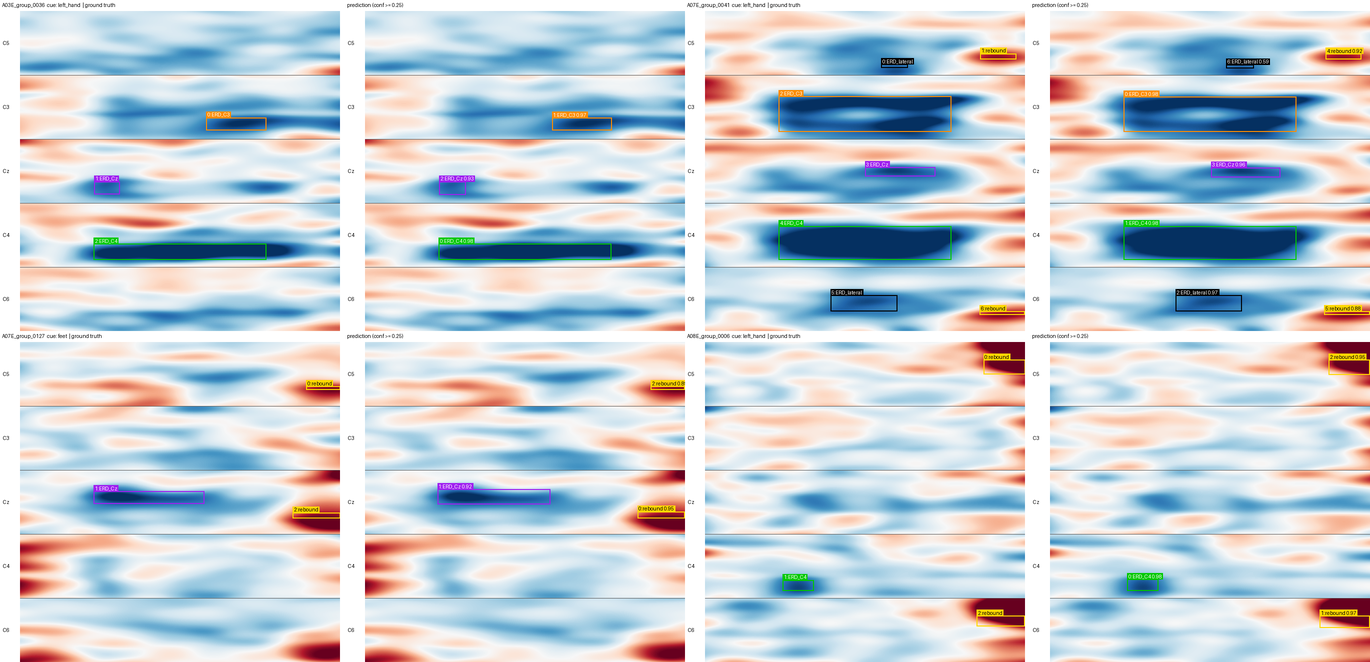

In [2]:
good = err[(err["n_gt"] >= 3) & (err["fp"] == 0) & (err["fn"] == 0)]
print(len(good), "such images out of", len(err))
sel = good.sample(n=4, random_state=0)["image"]
g = grid([pair(s) for s in sel], n_cols=2)
g.save(F / "gallery_good.png")
g

## Failure cases

Images with the most missed boxes, then the most false positives.

,image,subject,cue,n_gt,tp,fp,fn
11,A01E_group_0011,A01,left_hand,4,2,1,2
403,A03E_group_0003,A03,left_hand,3,1,1,2
1609,A09E_group_0009,A09,left_hand,5,4,7,1
1630,A09E_group_0030,A09,left_hand,5,4,7,1


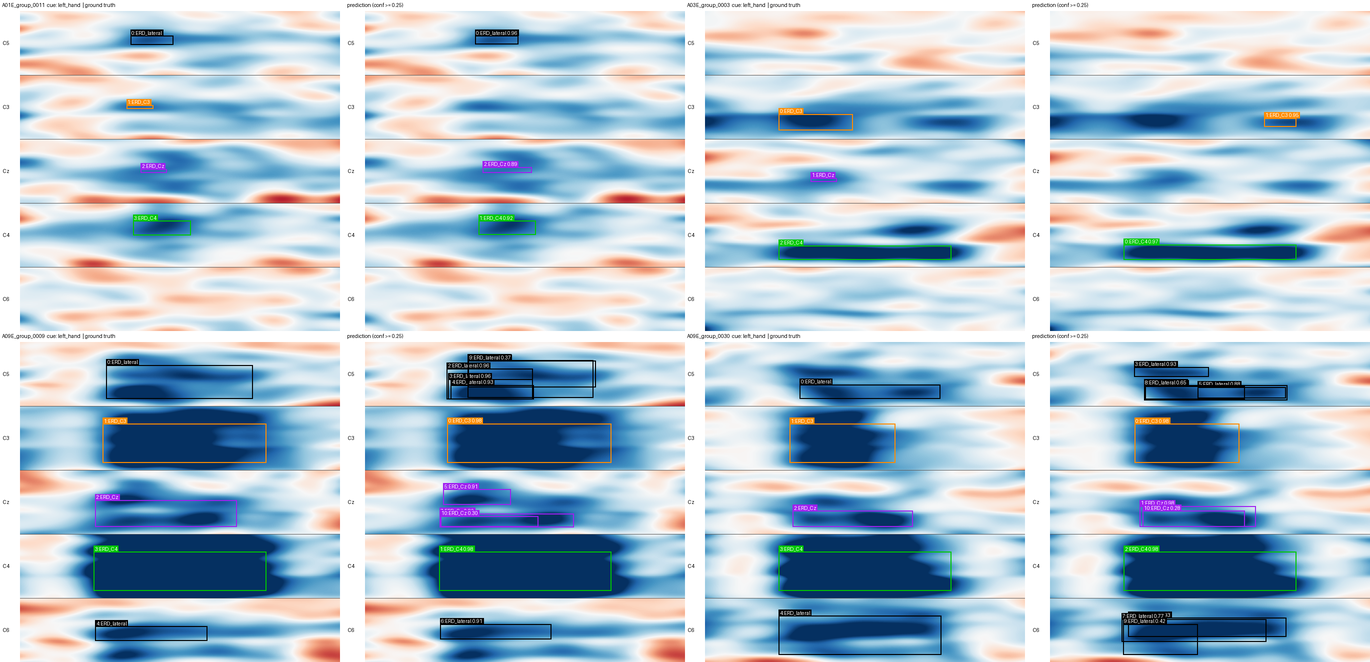

In [3]:
worst = err.sort_values(["fn", "fp"], ascending=False).head(4)
display(worst)
g = grid([pair(s) for s in worst["image"]], n_cols=2)
g.save(F / "gallery_failures.png")
g

### What are the false positives?

For every false positive (confidence ≥ 0.25, no ground-truth box of its class with IoU ≥ 0.5) the best IoU with any
ground-truth box is checked: a partial overlap means a localization error on a real event; no overlap means a box on
a region the label rule did not mark (often a sub-threshold decrease or increase that is visible in the image).

In [4]:
rows = []
for s, p in preds.items():
    keep = p["scores"] >= CONF_THR
    ious = iou_matrix(p["boxes"][keep], gt[s]["boxes"])
    for i, (lab, sc) in enumerate(zip(p["labels"][keep], p["scores"][keep])):
        same = ious[i][gt[s]["labels"] == lab] if len(gt[s]["labels"]) else np.array([])
        if same.size and same.max() >= 0.5:
            continue
        best = ious[i].max() if ious.shape[1] else 0.0
        rows.append({"image": s, "class": classes[lab], "score": sc,
                     "kind": "no overlap" if best == 0 else ("partial overlap" if best < 0.5 else "other class")})
fp = pd.DataFrame(rows)
display(fp.groupby(["class", "kind"]).size().unstack(fill_value=0))
fp.groupby("kind")["score"].describe()

kind,no overlap,other class,partial overlap
class,,,
ERD_C3,32,1,6
ERD_C4,30,4,9
ERD_Cz,28,0,19
ERD_lateral,56,0,44
ERS_rebound,90,0,14


,count,mean,std,min,25%,50%,75%,max
kind,,,,,,,,
no overlap,236.0,0.758669,0.202289,0.25303,0.637445,0.839125,0.917323,0.97055
other class,5.0,0.368656,0.103149,0.26701,0.315600,0.338960,0.384930,0.53678
partial overlap,92.0,0.749503,0.228208,0.25048,0.612012,0.844080,0.932162,0.98497


## Tongue and feet imagery

Tongue groups rarely contain an ERD box, which is why decoding fails for them (E5). The table counts, per cue, the
share of test groups with a ground-truth or predicted box of each class.

In [5]:
rows = []
for s, g in gt.items():
    p = preds[s]
    keep = p["scores"] >= CONF_THR
    for src, labels in (("ground truth", g["labels"]), ("prediction", p["labels"][keep])):
        rows.append({"cue": info.loc[s, "class_name"], "source": src,
                     **{c: int(i in set(labels.tolist())) for i, c in enumerate(classes)}})
share = pd.DataFrame(rows).groupby(["cue", "source"]).mean().mul(100).round(1)
share

ERD_C4  ERD_C3  ERD_Cz  ERD_lateral  ERS_rebound
cue        source                                                        
feet       ground truth     4.2     5.8    15.6          2.4         42.2
           prediction       4.4     6.9    15.3          2.7         43.1
left_hand  ground truth    51.6    35.6    24.9         23.6         23.3
           prediction      50.9    36.4    25.8         25.1         26.2
right_hand ground truth    20.2    34.7    10.4         14.4         26.4
           prediction      20.2    35.6    11.6         15.3         29.1
tongue     ground truth     2.2     0.7     0.9          1.1         21.8
           prediction       2.2     0.7     0.7          2.0         23.8

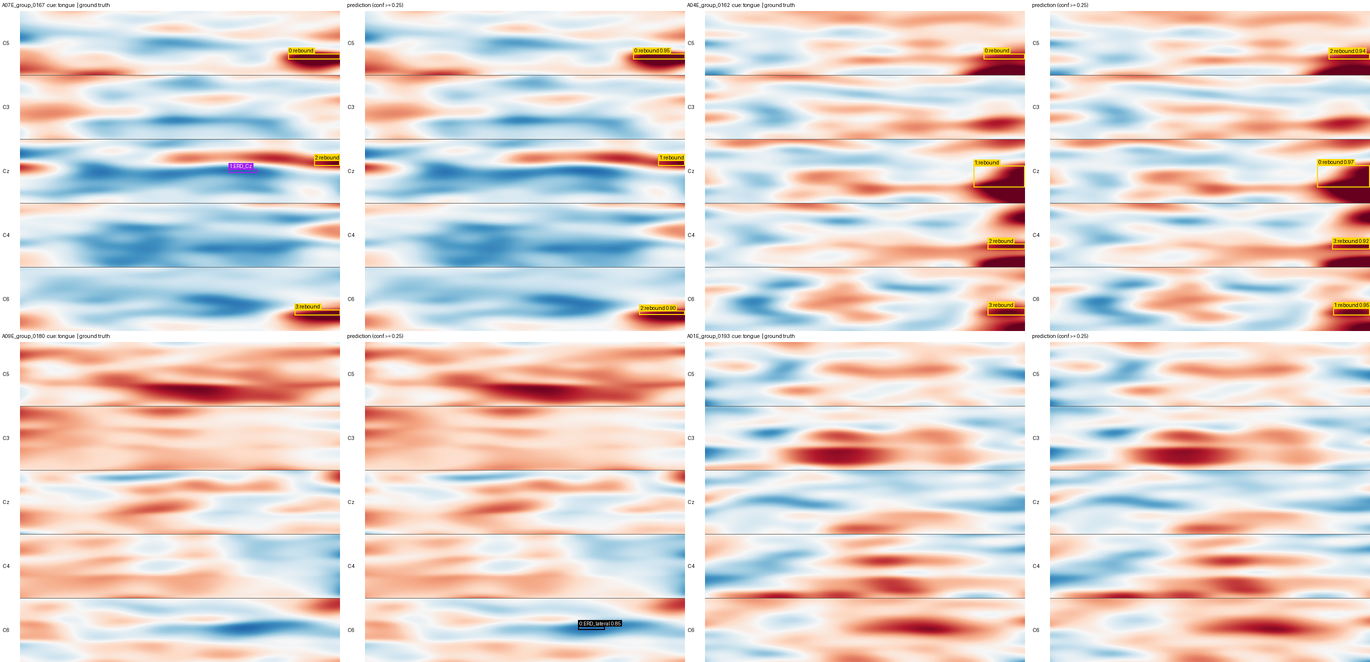

In [6]:
tongue = err[err["cue"] == "tongue"].sort_values("n_gt", ascending=False)
sel = list(tongue["image"].head(2)) + list(tongue.sample(n=2, random_state=1)["image"])
g = grid([pair(s) for s in sel], n_cols=2)
g.save(F / "gallery_tongue.png")
g

Tongue groups mainly show power *increases* over the hand areas (red on C3/C4, cf. the grand average in
`dataset_and_erd.ipynb`) and only occasionally an ERD on C5/C6. With location-based classes this means tongue
imagery leaves no `ERD_lateral` box to decode from in most groups.

## The same group under increasing noise

One test group of a strong subject at every noise level of E4, with the detector's predictions. The ground truth
always comes from the clean data.

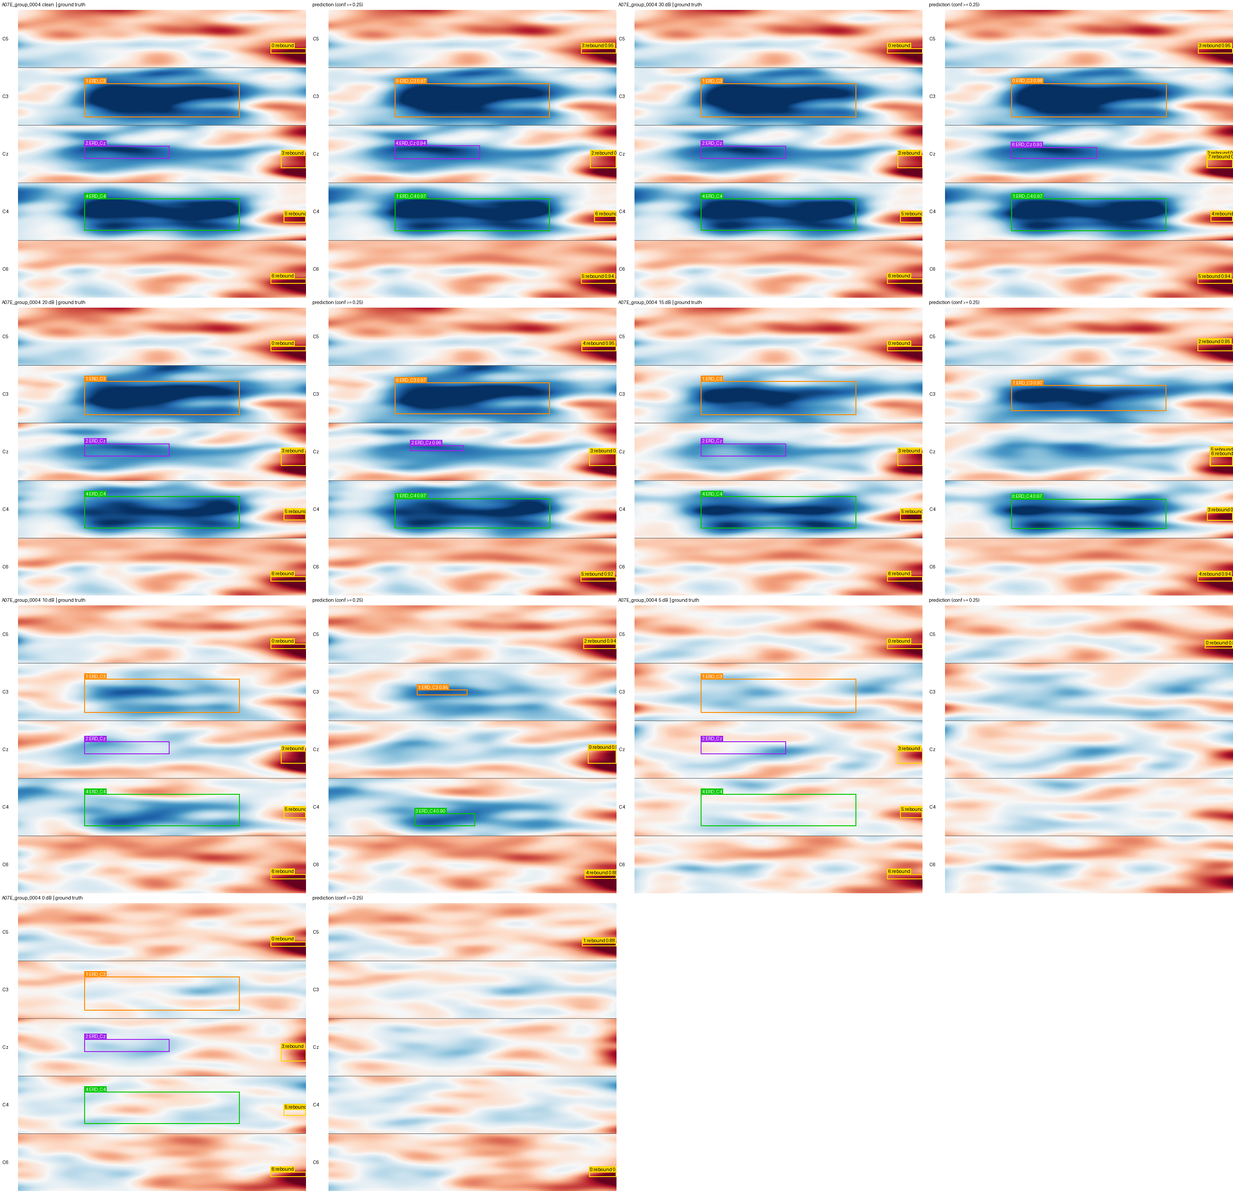

In [7]:
best_subject = err.groupby("subject")["tp"].sum().idxmax()
stem = err[(err["subject"] == best_subject) & (err["fn"] == 0)].sort_values("n_gt", ascending=False)["image"].iloc[0]
levels = [("clean", RUN, img_dir)] + [(f"{s} dB", f"{RUN}_snr{s}", resolve(f"dataset/yolo/test_noise_snr{s}/images/test"))
                                      for s in (30, 20, 15, 10, 5, 0)]
frames = []
for name, run, root in levels:
    p, _ = load_predictions(run, "test")
    frames.append(pair(stem, f"{stem}  {name}", img_root=root, p=p))
g = grid(frames, n_cols=2, scale=0.45)
g.save(F / "noise_series.png")
save_gif([f.resize((f.width // 2, f.height // 2)) for f in frames], F / "noise_series.gif", seconds_per_frame=1.5)
g

## Detections across groups (GIF)

Successive right-hand test groups of the same subject: the contralateral `ERD_C3` box is found repeatedly, with
variable extent and occasional ipsilateral `ERD_C4` boxes.

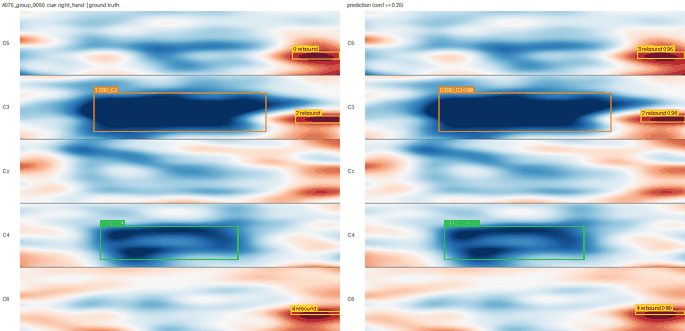

In [8]:
stems = err[(err["subject"] == best_subject) & (err["cue"] == "right_hand")]["image"].head(12)
frames = [pair(s) for s in stems]
save_gif([f.resize((f.width // 2, f.height // 2)) for f in frames], F / f"detections_{best_subject}_right_hand.gif")
display(IPImage(filename=str(F / f"detections_{best_subject}_right_hand.gif")))